0    1.25372
1    1.23378
2    1.20766
3    1.19457
4    1.17574
Name: SpotPriceDKK, dtype: float64
Loading demand profiles...
Demand profiles loaded!
Loading production data...
Production profiles loaded!
2.535
3.3217833333333333


/Users/antonlenander/anaconda3/envs/phantom/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-30 12:49:31,313	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-01-30 12:49:31,370	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-01-30 12:49:31,776	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!


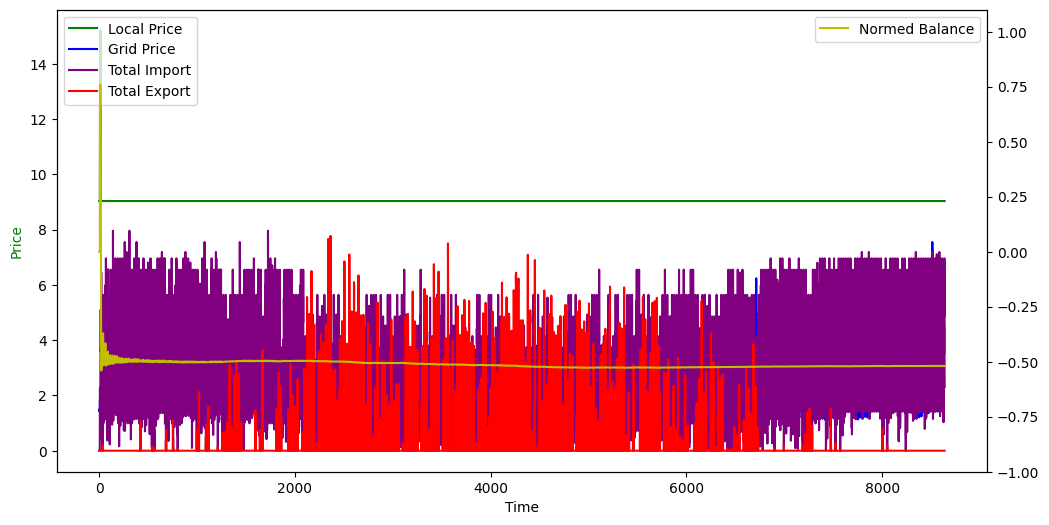

-0.511059900572638
-0.5195194266688292



In [1]:
import matplotlib.pyplot as plt
import cloudpickle
import numpy as np
from datamanager import DataManager

path = "output/flex_multi_combined/results.pkl"
outputfolder = path
with open(path, "rb") as file:
    results = cloudpickle.load(file)
results = list(results)

for rollout in results:
    aid = "CM"
    prices = []
    norm_balance = []
    grid_price = []
    prosumers_loss = []
    mediator_loss = []
    total_export = []
    total_import = []
    total_import += list(rollout.metrics["cm/total_import"])
    total_export += list(rollout.metrics["cm/total_export"])
    prosumers_loss += list(rollout.metrics["env/total_loss"])
    mediator_loss += list(rollout.metrics["cm/mediator_netloss"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    prices += list(rollout.metrics["env/current_price"])

    start = 0
    end = start + 48*30*12

    total_import = total_import[start+1:end+1:2]
    total_export = total_export[start+1:end+1:2]
    prosumers_loss = prosumers_loss[start:end:2]
    mediator_loss = mediator_loss[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]
    prices = prices[start:end:2]

    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax1.plot(total_import, color="purple", label="Total Import")
    ax1.plot(total_export, color="red", label="Total Export")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    #ax2.plot(prosumers_loss, 'r-', label="prosumers loss")
    #ax2.plot(total_export, 'k-', label="Total Export")
    ax2.set_ylim(-1, 1.1)
    #ax1.set_ylim(0, 8)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

    print(np.mean(norm_balance))
    print(norm_balance[len(norm_balance)-1])
    print()

   

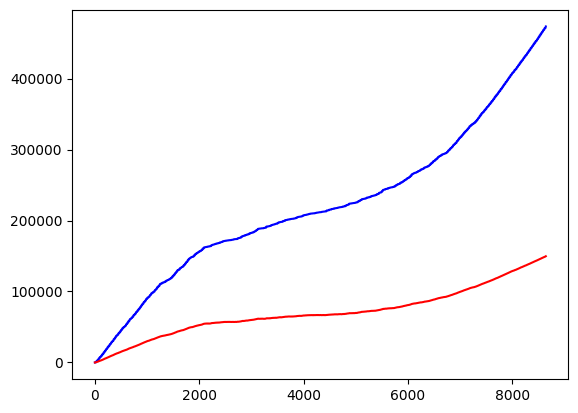

In [2]:
plt.plot(mediator_loss, color='blue')
plt.plot(prosumers_loss, color='red')
# plt.plot(total_export, color='green')
plt.show()